# 📊 Loan Default Analysis — Exploratory Data Analysis (EDA)

---

## 📝 Introduction

In the financial industry, evaluating loan risk is one of the most critical tasks for banks and lending institutions. Incorrect risk assessment can lead to significant financial losses due to borrower defaults.

This notebook performs an **Exploratory Data Analysis (EDA)** on a loan dataset to understand borrower characteristics, identify financial risk patterns, and uncover insights that influence loan approval and default behavior.

The goal of this project is to strengthen financial analytics skills while applying data-driven techniques to a real-world lending dataset.

---

## 🎯 Objectives

The primary objectives of this notebook are:

- Understand the structure and features of the dataset.
- Perform data cleaning and preprocessing.
- Analyze borrower demographics and financial attributes.
- Identify key factors influencing loan default.
- Generate business insights and risk-based recommendations.

---

## 🏦 Business Context

Banks evaluate multiple financial and demographic factors before approving loans, such as:

- Income level
- Credit history
- Loan amount
- Debt-to-income ratio
- Employment status

Through this analysis, we aim to answer the following questions:

- What patterns exist in loan approvals and defaults?
- Which financial indicators strongly influence loan risk?
- How can data-driven insights improve lending decisions?

---

## 📂 Dataset Overview

The dataset contains information about loan applicants, including financial, demographic, and credit-related attributes. It includes a target variable indicating whether the loan was approved or defaulted.

This analysis will explore:

- Numerical feature distributions  
- Categorical feature relationships  
- Correlation patterns  
- Risk segmentation  

---




## 01: 📝 Importing required libraries 


In [1]:

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Statistical tools
from scipy import stats

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


## 02: Load Dataset


In [2]:

df = pd.read_csv('/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv')  

print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 03.Data Understanding

Before performing any analysis, it is important to understand the structure and features of the dataset.

In this section, we will:

- Check dataset shape
- Inspect column names
- Examine data types
- Review summary statistics
- Identify missing values

Understanding the dataset structure helps in designing the right analytical approach.


In [3]:

# 1. Shape of dataset
print("Dataset Shape (Rows, Columns):")
print(df.shape)


Dataset Shape (Rows, Columns):
(255347, 18)


In [4]:
# 2. Column names
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')


In [5]:
# 3. Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object


In [6]:
# 4. First 5 rows
print("\nPreview of Dataset:")
display(df.head())


Preview of Dataset:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
# 5. Summary statistics (Numerical)
print("\nSummary Statistics (Numerical Features):")
display(df.describe())


Summary Statistics (Numerical Features):


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [8]:
# 6. Summary statistics (Categorical)
print("\nSummary Statistics (Categorical Features):")
display(df.describe(include='object'))


Summary Statistics (Categorical Features):


,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,ZTH91CGL0B,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701


In [9]:
# 7. Missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


## 04. Business Understanding & Analytical Questions

To perform meaningful financial analysis, we must define business-driven questions.

Banks want to understand:

- Who is likely to default?
- What borrower characteristics increase financial risk?
- How does income affect loan approval?
- Does credit history influence loan decisions?
- Are higher loan amounts associated with higher default rates?

In this section, we define the key variables and prepare for analysis.


In [10]:
df["Default"].unique()


array([0, 1])

In [11]:


target_column = "Default"

print("Target Variable Distribution:")
print(df[target_column].value_counts())

print("\nTarget Variable Percentage Distribution:")
print(df[target_column].value_counts(normalize=True) * 100)


Target Variable Distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Target Variable Percentage Distribution:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


## 05. Univariate Analysis

Univariate analysis focuses on understanding the distribution of individual variables.

We will analyze:

- Distribution of numerical variables
- Distribution of categorical variables
- Detection of skewness and outliers

This helps us understand the overall financial profile of borrowers.


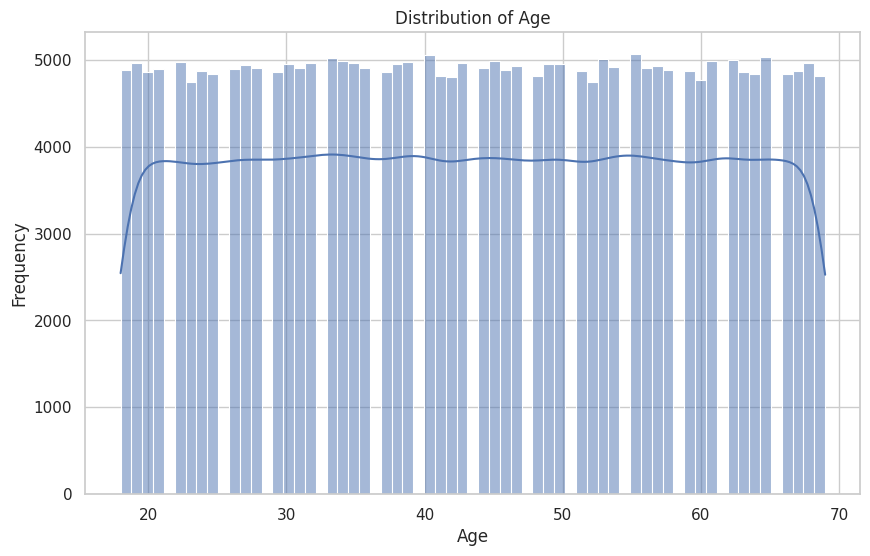

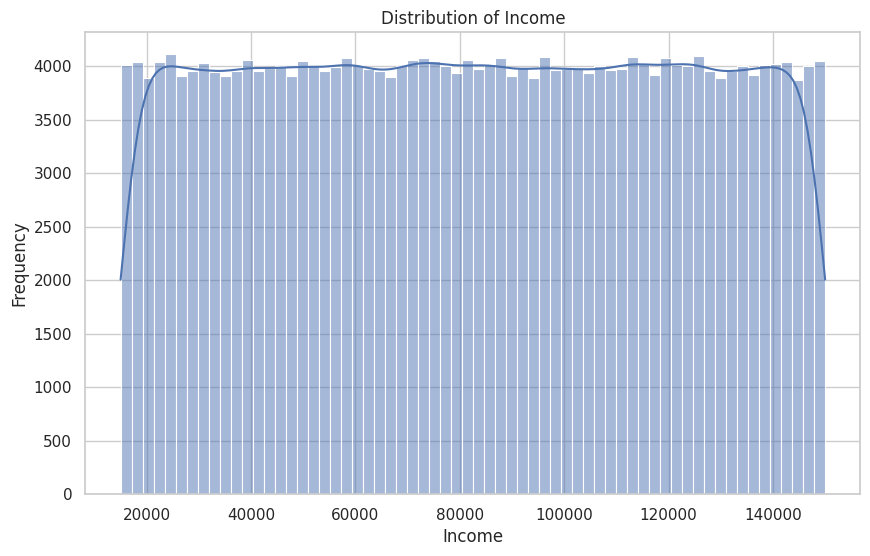

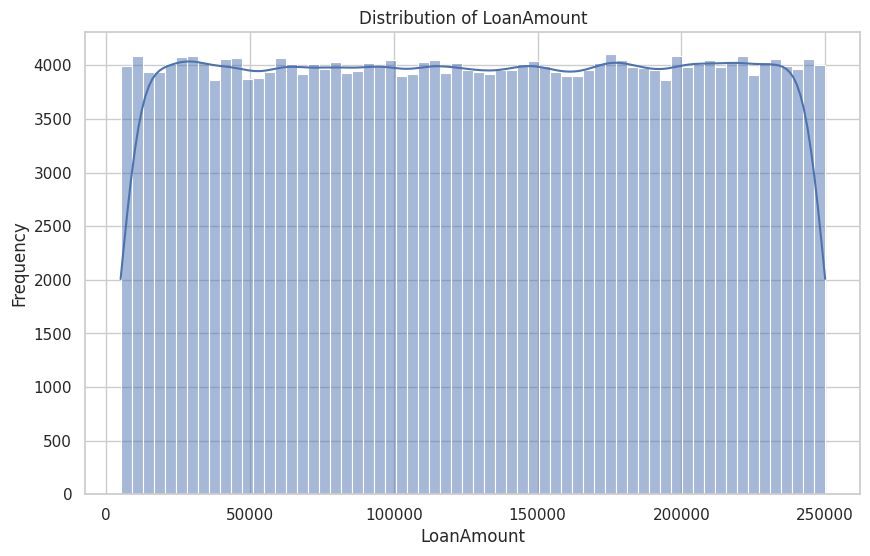

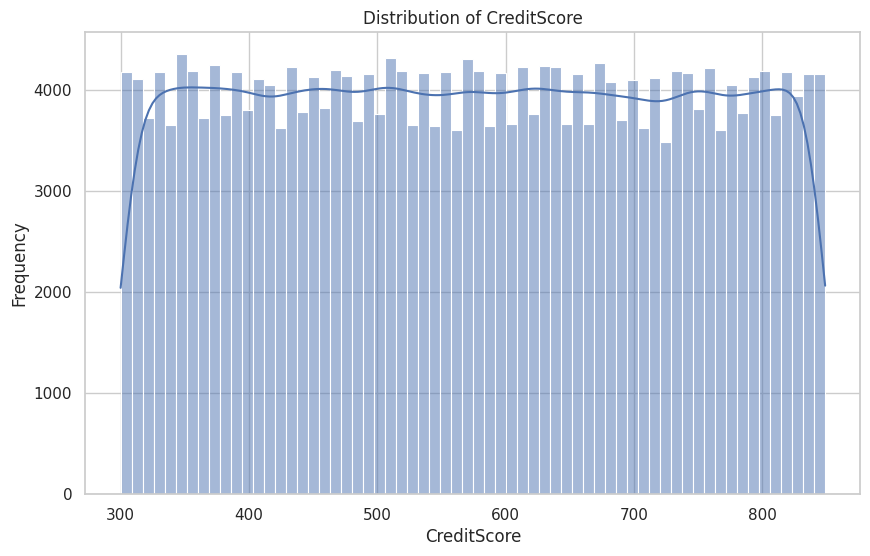

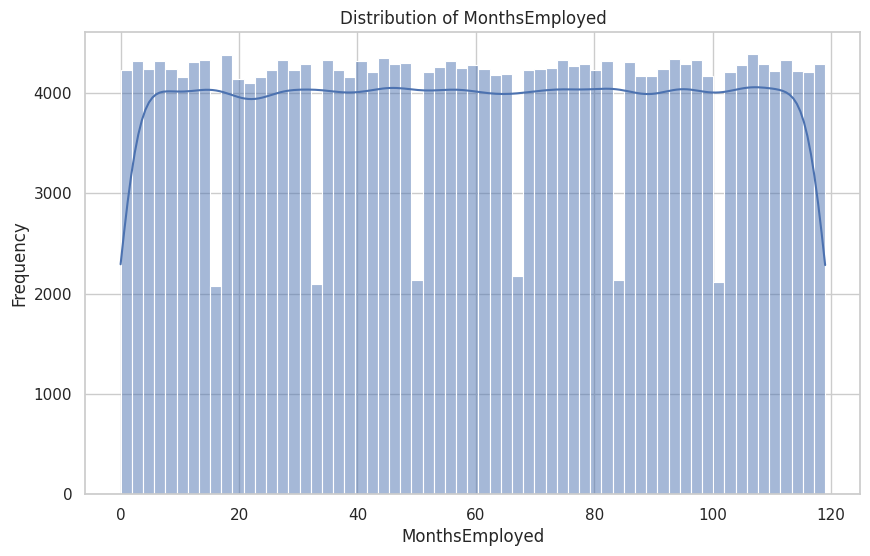

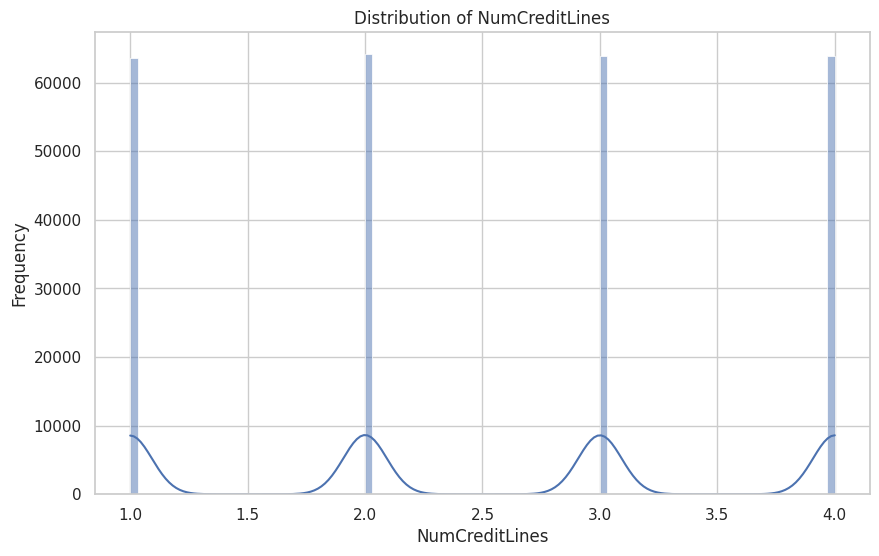

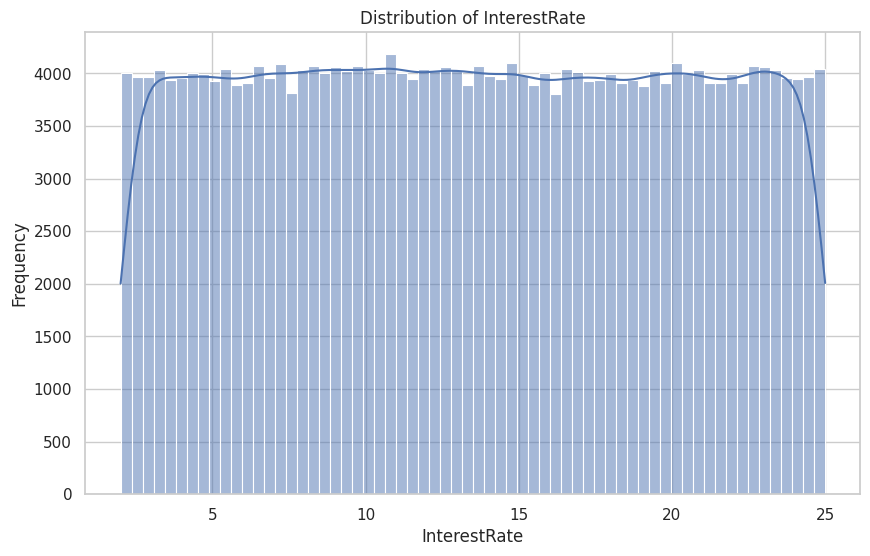

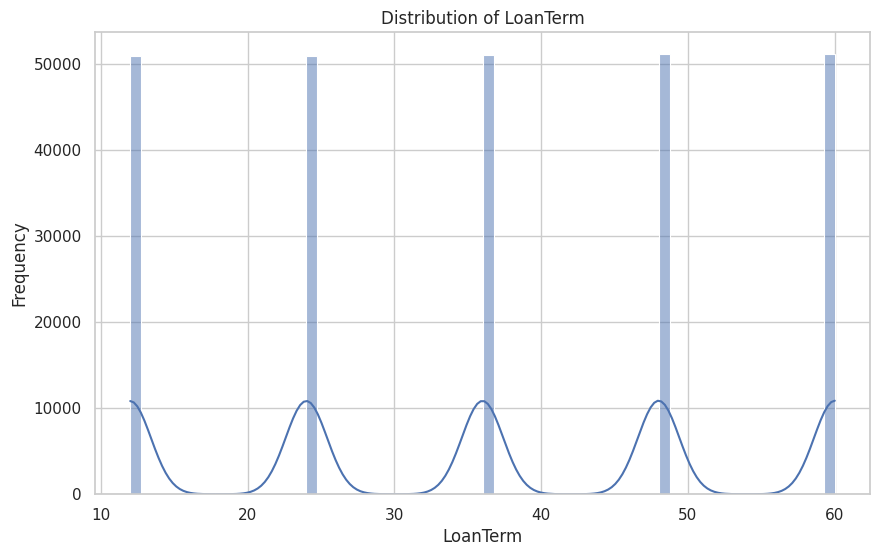

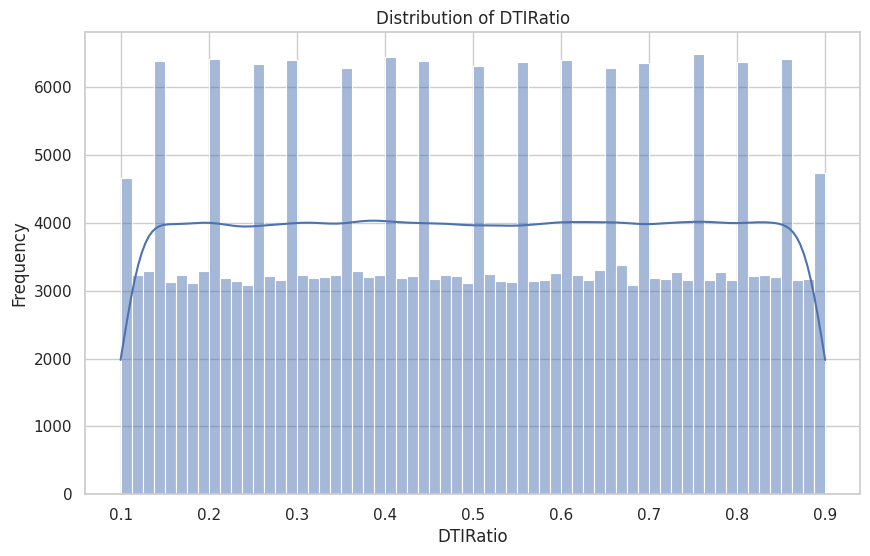

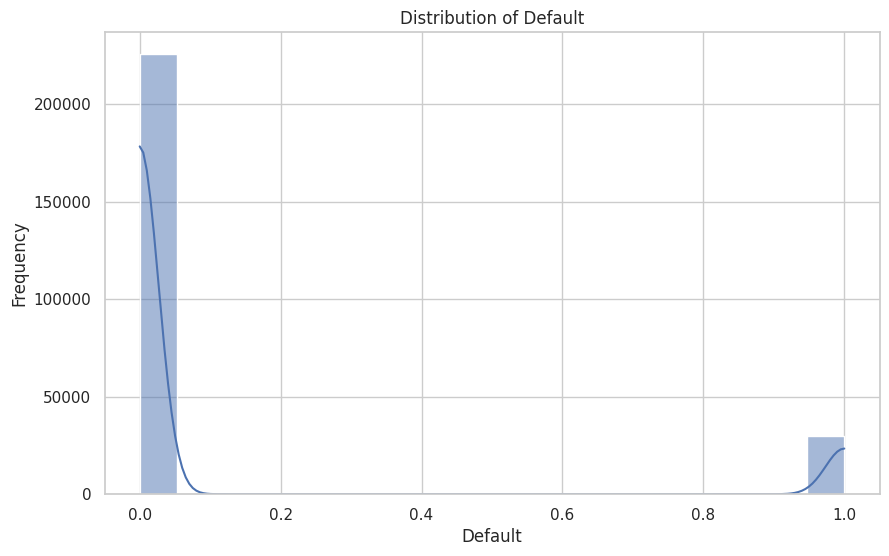

In [12]:


numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


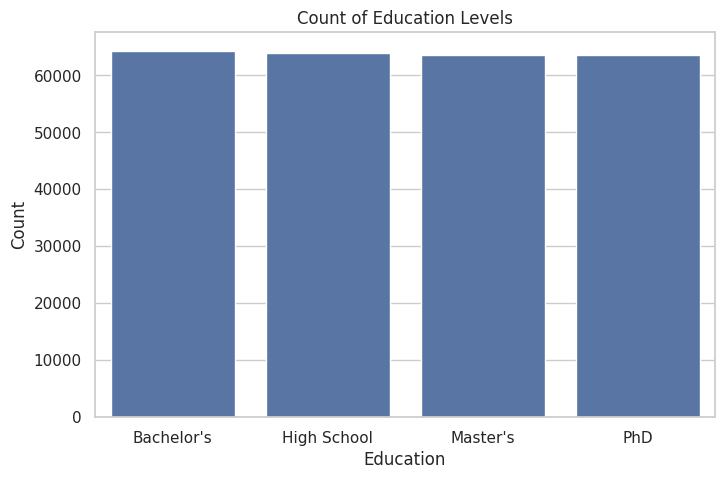

In [13]:
# Plot only one categorical column to save time
plt.figure(figsize=(8,5))
sns.countplot(x='Education', data=df, order=df['Education'].value_counts().index)
plt.title('Count of Education Levels')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()


## 06. Bivariate Analysis — Relationship with Default

In this section, we analyze how different borrower characteristics influence loan default.

We will explore:

- Numerical variables vs Default
- Categorical variables vs Default
- Risk patterns across financial indicators

This helps identify high-risk borrower segments and key drivers of default.


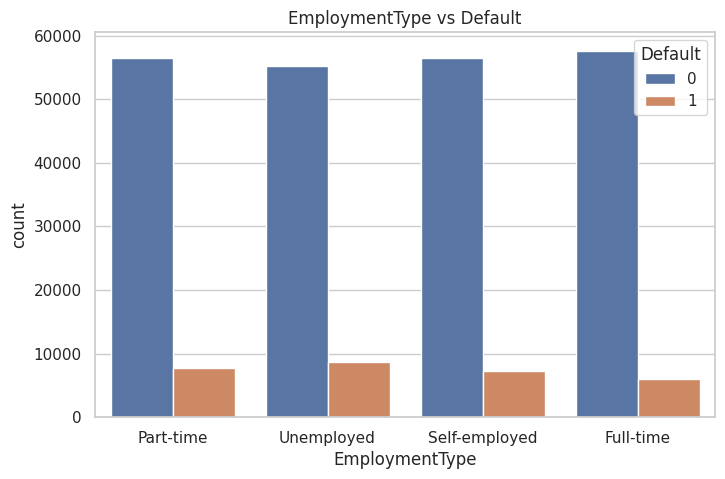

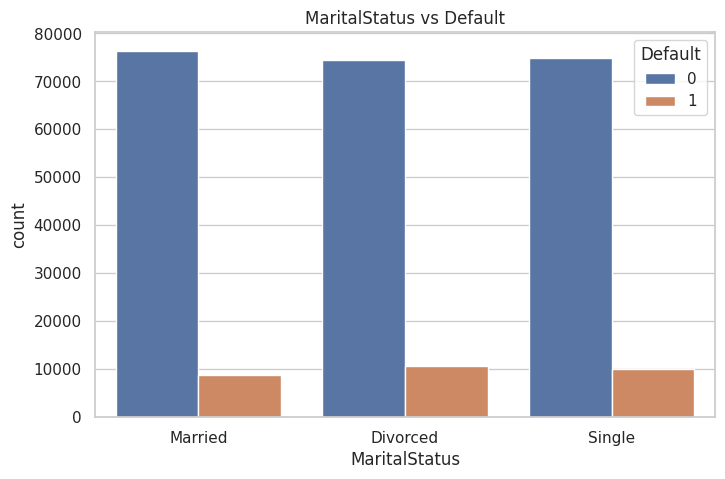

In [14]:
# ===============================
# 6B. CATEGORICAL FEATURES VS DEFAULT (Pick 2 columns)
# ===============================

categorical_cols = ['EmploymentType', 'MaritalStatus']  # pick 2 important columns

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, hue='Default', data=df, order=df[col].value_counts().index)
    plt.title(f'{col} vs Default')
    plt.show()


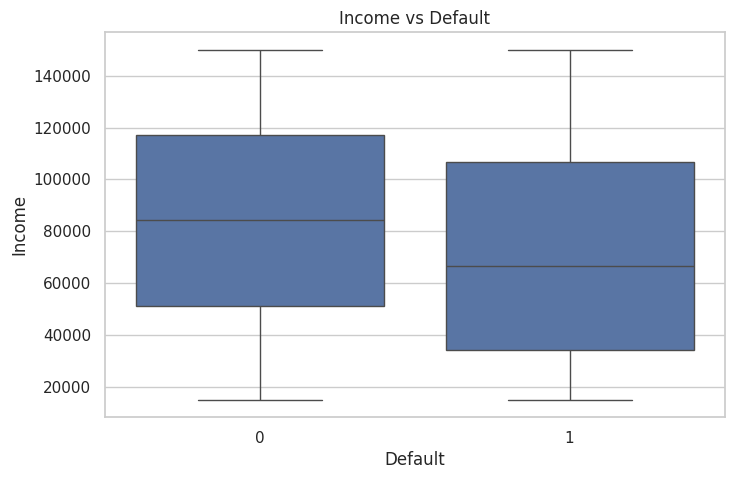

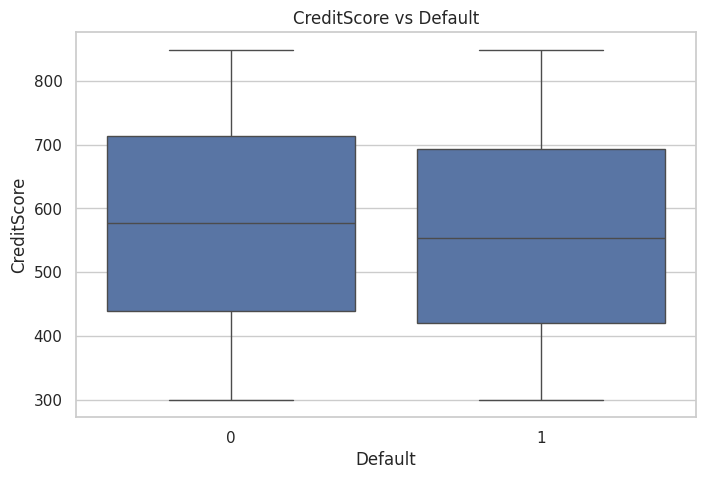

In [15]:
# ===============================
# 6A. NUMERICAL FEATURES VS DEFAULT (Sampled 2 columns)
# ===============================

numerical_cols = ['Income', 'CreditScore']  # pick 2 important columns
target_column = 'Default'

for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=target_column, y=col, data=df)
    plt.title(f'{col} vs Default')
    plt.show()

## 07. Conclusion, Summary & Insights

In this project, we analyzed a financial loan dataset to understand what makes a borrower likely to default (fail to repay a loan). The main goal was to find **patterns and risks** in the data that banks or financial institutions can use to make smarter decisions.

---

## 🔹 Key Findings from Numerical Analysis

- **Income**: Borrowers with **lower income** tend to default more.  
- **Credit Score**: Borrowers with **lower credit scores** have a higher chance of default.  
- **Debt-to-Income Ratio (DTI)**: Higher DTI indicates that a borrower owes more compared to what they earn → higher risk.  

**Layman interpretation:** People who earn less, have bad credit history, or owe more than they earn are more likely to not repay loans.

---

## 🔹 Key Findings from Categorical Analysis

- **Employment Type**: Part-time or unstable jobs are linked to higher default rates.  
- **Marital Status**: Single borrowers showed slightly higher default rates than married ones.  
- **Co-signer / Mortgage**: Having a co-signer or mortgage tends to reduce default risk.  

**Layman interpretation:** Job stability, marital support, and co-signers help reduce the risk of not repaying the loan.

---

## 🔹 Overall Insights

- Creditworthiness (Credit Score) and financial stability (Income, DTI) are the **biggest factors** affecting loan repayment.  
- Both **numerical and categorical factors** give important information for banks to make decisions.  
- This analysis can help banks:  
  - Approve loans for low-risk borrowers  
  - Adjust interest rates based on risk  
  - Encourage co-signers or reduce loan amounts for high-risk borrowers  

---

## 🔹 Final Takeaway

**Default = Risk of not repaying loan**  
By looking at income, credit score, job type, and personal factors, we can **predict who is more likely to default** and reduce financial losses.  

> This project shows how simple data analysis can **guide smarter loan decisions** in banking.
